Hey, I'm gonna import the basic packages necessary, load the datasets, parse and validate them and visualize them with plots here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
features = pd.read_csv('data-walmart-sales/features.csv')
stores = pd.read_csv('data-walmart-sales/stores.csv')
train = pd.read_csv('data-walmart-sales/train.csv')

In [3]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [7]:
print("train:", train.shape, "| features:", features.shape, "| stores:", stores.shape)
print("train date range:", train["Date"].min(), "to", train["Date"].max())
print("features date range:", features["Date"].min(), "to", features["Date"].max())

train: (421570, 5) | features: (8190, 12) | stores: (45, 3)
train date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
features date range: 2010-02-05 00:00:00 to 2013-07-26 00:00:00


In [8]:
dup_train = train.duplicated(subset=["Store","Dept","Date"]).sum()
dup_feat  = features.duplicated(subset=["Store","Date"]).sum()
print("Duplicate rows - train(Store,Dept,Date):", dup_train)
print("Duplicate rows - features(Store,Date):", dup_feat)

Duplicate rows - train(Store,Dept,Date): 0
Duplicate rows - features(Store,Date): 0


Selecting Store = 1 and dept = 1

In [9]:
df = train[(train["Store"] == 1) & (train["Dept"] == 1)].copy()
df = df.sort_values("Date")

In [10]:
print("Rows for Store 1 Dept 1:", len(df))
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Rows for Store 1 Dept 1: 143
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


In [11]:
date_diffs = df["Date"].diff().dropna().dt.days
print("Unique day gaps:", sorted(date_diffs.unique())[:10], "...")
print("Any gaps not equal to 7?", (date_diffs != 7).any())

Unique day gaps: [7] ...
Any gaps not equal to 7? False


All clear till now, creating a proper time series and moving to visualisation

In [12]:
ts = df.set_index("Date")[["Weekly_Sales", "IsHoliday"]].copy()

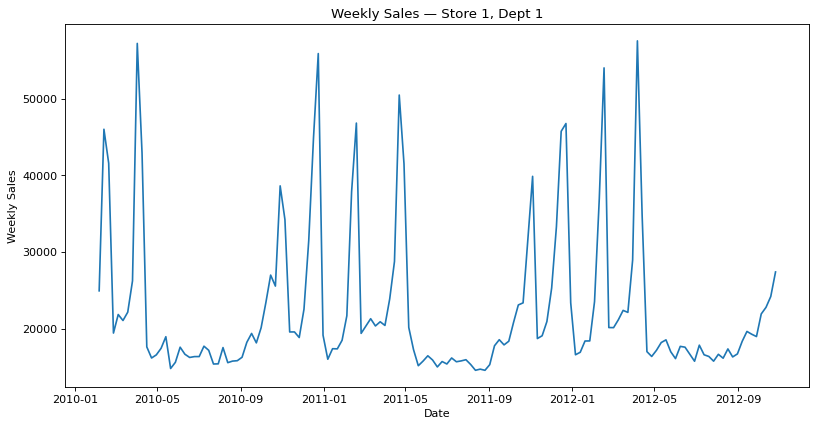

In [13]:
plt.figure(figsize=(12, 6), dpi=80)
plt.plot(ts.index, ts["Weekly_Sales"])
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales — Store 1, Dept 1")
plt.show()

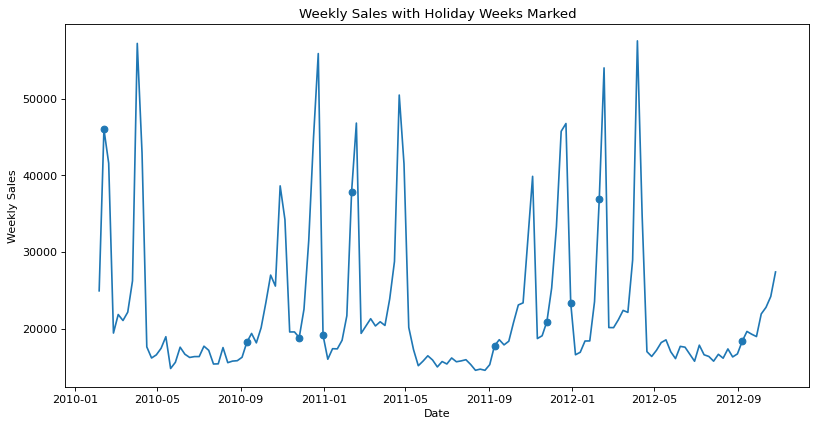

In [14]:
hol = ts[ts["IsHoliday"] == True]
plt.figure(figsize=(12, 6), dpi=80)
plt.plot(ts.index, ts["Weekly_Sales"])
plt.scatter(hol.index, hol["Weekly_Sales"])  # markers default style
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales with Holiday Weeks Marked")
plt.show()

In [15]:
ts.head(), ts.shape, ts.index.min(), ts.index.max()


(            Weekly_Sales  IsHoliday
 Date                               
 2010-02-05      24924.50      False
 2010-02-12      46039.49       True
 2010-02-19      41595.55      False
 2010-02-26      19403.54      False
 2010-03-05      21827.90      False,
 (143, 2),
 Timestamp('2010-02-05 00:00:00'),
 Timestamp('2012-10-26 00:00:00'))

Comparing Sales on Holidays and Non-Holidays

In [16]:
holiday = ts[ts["IsHoliday"] == True]["Weekly_Sales"]
nonholiday = ts[ts["IsHoliday"] == False]["Weekly_Sales"]

summary = pd.DataFrame({
    "Group": ["Holiday", "Non-Holiday"],
    "Count": [holiday.shape[0], nonholiday.shape[0]],
    "Mean": [holiday.mean(), nonholiday.mean()],
    "Median": [holiday.median(), nonholiday.median()],
    "Std": [holiday.std(), nonholiday.std()],
    "Min": [holiday.min(), nonholiday.min()],
    "Max": [holiday.max(), nonholiday.max()],
})

summary


,Group,Count,Mean,Median,Std,Min,Max
0,Holiday,10,25738.594000,20017.915,10449.177415,17746.68,46039.49
1,Non-Holiday,133,22270.821353,18461.180,9806.789092,14537.37,57592.12


In [17]:
lift_pct = (holiday.mean() / nonholiday.mean() - 1) * 100
print(f"Average holiday lift vs non-holiday: {lift_pct:.2f}%")


Average holiday lift vs non-holiday: 15.57%


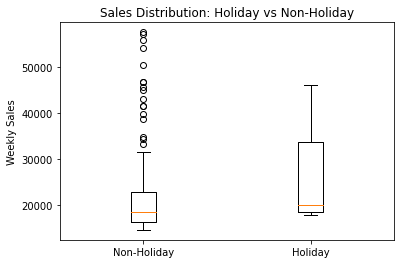

In [18]:
plt.figure()
plt.boxplot([nonholiday.values, holiday.values], labels=["Non-Holiday", "Holiday"])
plt.ylabel("Weekly Sales")
plt.title("Sales Distribution: Holiday vs Non-Holiday")
plt.show()


Getting into Monthly seasonality

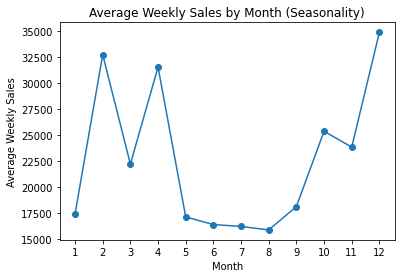

Month
1     17418.992500
2     32700.750833
3     22210.847692
4     31512.416429
5     17144.904167
6     16412.754615
7     16231.430714
8     15898.948462
9     18139.044615
10    25361.224615
11    23837.363750
12    34849.595000
Name: Weekly_Sales, dtype: float64

In [19]:
ts_month = ts.copy()
ts_month["Month"] = ts_month.index.month

monthly_avg = ts_month.groupby("Month")["Weekly_Sales"].mean()

plt.figure()
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.title("Average Weekly Sales by Month (Seasonality)")
plt.show()

monthly_avg


Inference : Lesser sales from May - September

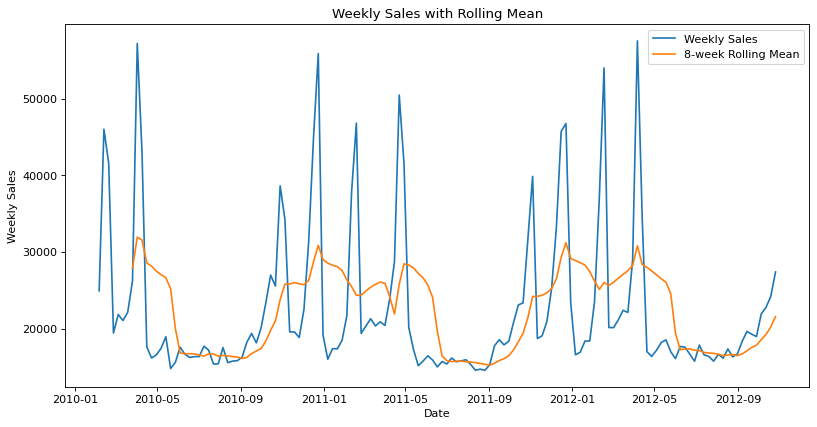

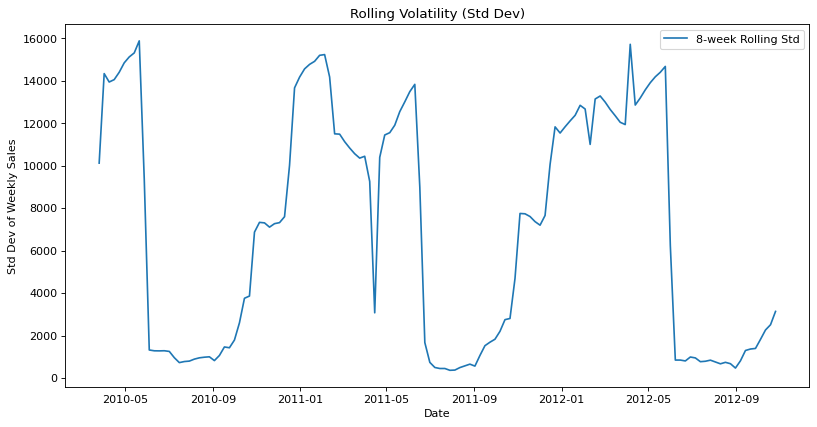

In [20]:
win = 8  # try 12 as well
roll_mean = ts["Weekly_Sales"].rolling(window=win).mean()
roll_std  = ts["Weekly_Sales"].rolling(window=win).std()

plt.figure(figsize=(12, 6), dpi=80)
plt.plot(ts.index, ts["Weekly_Sales"], label="Weekly Sales")
plt.plot(roll_mean.index, roll_mean, label=f"{win}-week Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.title("Weekly Sales with Rolling Mean")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6), dpi=80)
plt.plot(roll_std.index, roll_std, label=f"{win}-week Rolling Std")
plt.xlabel("Date")
plt.ylabel("Std Dev of Weekly Sales")
plt.title("Rolling Volatility (Std Dev)")
plt.legend()
plt.show()


In [21]:
import numpy as np

y = ts["Weekly_Sales"]
z = (y - y.mean()) / y.std()

outliers = ts[np.abs(z) > 3].copy()  # threshold 3 std dev
outliers[["Weekly_Sales", "IsHoliday"]].sort_values("Weekly_Sales", ascending=False).head(10)


,Weekly_Sales,IsHoliday
Date,,
2012-04-06,57592.12,False
2010-04-02,57258.43,False
2010-12-24,55931.23,False
2012-02-17,54060.10,False


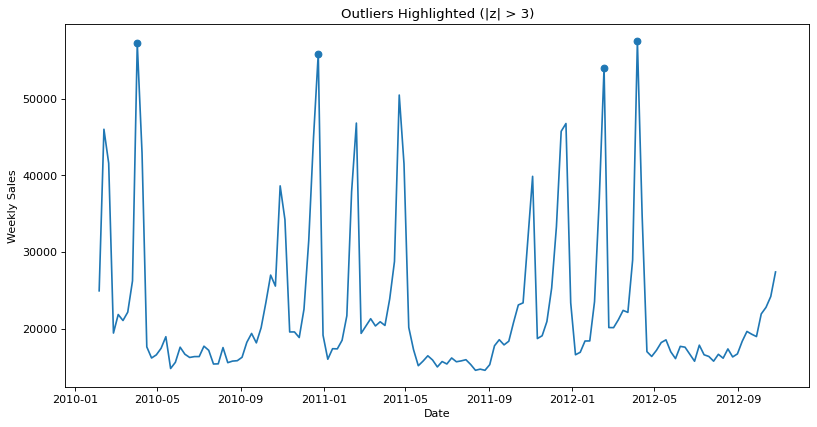

In [22]:
plt.figure(figsize=(12, 6), dpi=80)
plt.plot(ts.index, ts["Weekly_Sales"])
plt.scatter(outliers.index, outliers["Weekly_Sales"])
plt.title("Outliers Highlighted (|z| > 3)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()


In [23]:
from statsmodels.tsa.stattools import adfuller

adf_stat, pvalue, usedlag, nobs, crit_vals, icbest = adfuller(ts["Weekly_Sales"].dropna())

print("ADF Statistic:", adf_stat)
print("p-value:", pvalue)
print("Used lag:", usedlag)
print("N observations:", nobs)
print("Critical values:", crit_vals)


ADF Statistic: -2.5221638686500403
p-value: 0.11017432282586914
Used lag: 6
N observations: 136
Critical values: {'1%': -3.4793722137854926, '5%': -2.8830370378332995, '10%': -2.578233635380623}


<Figure size 432x288 with 0 Axes>

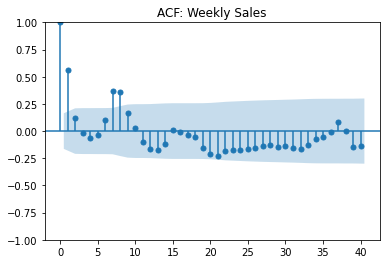

<Figure size 432x288 with 0 Axes>

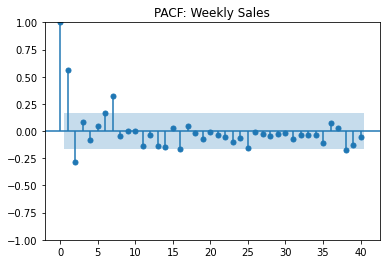

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure()
plot_acf(ts["Weekly_Sales"], lags=40)
plt.title("ACF: Weekly Sales")
plt.show()

plt.figure()
plot_pacf(ts["Weekly_Sales"], lags=40, method="ywm")
plt.title("PACF: Weekly Sales")
plt.show()


In [25]:
test_size = 26

y = ts["Weekly_Sales"].copy()
y_train = y.iloc[:-test_size]
y_test  = y.iloc[-test_size:]

print("Train:", y_train.index.min(), "to", y_train.index.max(), "| n =", len(y_train))
print("Test :", y_test.index.min(),  "to", y_test.index.max(),  "| n =", len(y_test))


Train: 2010-02-05 00:00:00 to 2012-04-27 00:00:00 | n = 117
Test : 2012-05-04 00:00:00 to 2012-10-26 00:00:00 | n = 26


### Hold Winters

In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

holt = ExponentialSmoothing(y_train, trend="add", seasonal=None)
holt_fit = holt.fit(optimized=True)

holt_forecast = holt_fit.forecast(steps=len(y_test))
holt_forecast.index = y_test.index
holt_forecast.head()


c:\Users\amrit\miniconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


Date
2012-05-04    16265.010552
2012-05-11    16176.312759
2012-05-18    16087.614965
2012-05-25    15998.917172
2012-06-01    15910.219379
dtype: float64

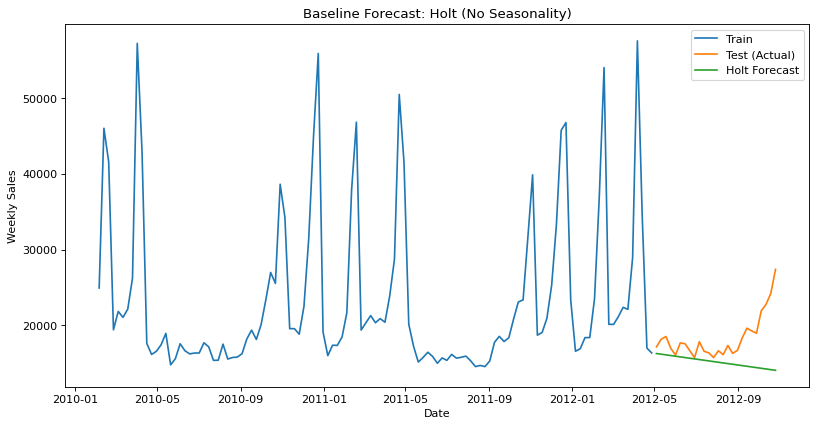

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), dpi=80)
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)")
plt.plot(holt_forecast.index, holt_forecast, label="Holt Forecast")
plt.title("Baseline Forecast: Holt (No Seasonality)")
plt.xlabel("Date"); plt.ylabel("Weekly Sales")
plt.legend()
plt.show()


In [28]:
from prophet import Prophet

prophet_train = y_train.reset_index()
prophet_train.columns = ["ds", "y"]

m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
m.fit(prophet_train)

future = y_test.reset_index()
future.columns = ["ds", "y"]  # y column not required but harmless

forecast = m.predict(future[["ds"]])
prophet_forecast = forecast.set_index("ds")["yhat"]
prophet_forecast.index = y_test.index
prophet_forecast.head()


Importing plotly failed. Interactive plots will not work.
21:00:25 - cmdstanpy - INFO - Chain [1] start processing
21:00:26 - cmdstanpy - INFO - Chain [1] done processing


Date
2012-05-04    20484.004145
2012-05-11    18271.019920
2012-05-18    16041.873853
2012-05-25    14799.878806
2012-06-01    15190.864127
Name: yhat, dtype: float64

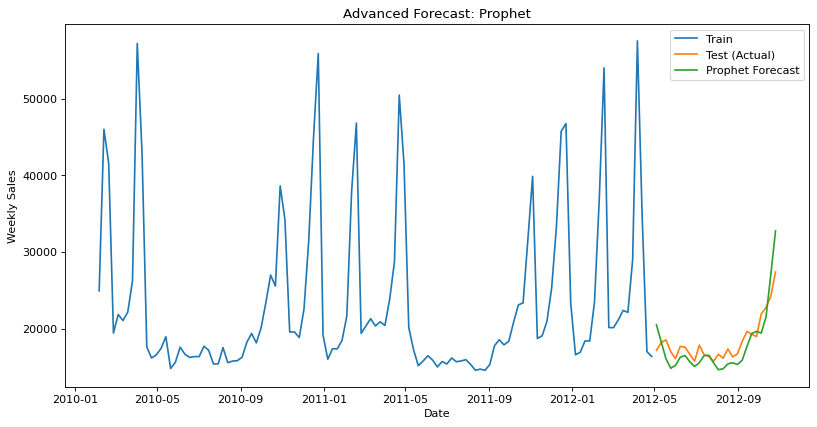

In [32]:
plt.figure(figsize=(12, 6), dpi=80)
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)")
plt.plot(prophet_forecast.index, prophet_forecast, label="Prophet Forecast")
plt.title("Advanced Forecast: Prophet")
plt.xlabel("Date"); plt.ylabel("Weekly Sales")
plt.legend()
plt.show()


In [30]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = pd.DataFrame({
    "Model": ["Holt (No Seasonality)", "Prophet"],
    "MAE": [
        mean_absolute_error(y_test, holt_forecast),
        mean_absolute_error(y_test, prophet_forecast)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, holt_forecast)),
        np.sqrt(mean_squared_error(y_test, prophet_forecast))
    ],
    "MAPE (%)": [
        mape(y_test, holt_forecast),
        mape(y_test, prophet_forecast)
    ]
})

results


,Model,MAE,RMSE,MAPE (%)
0,Holt (No Seasonality),3164.340325,4533.292853,15.417268
1,Prophet,1560.224849,1960.496281,8.181784


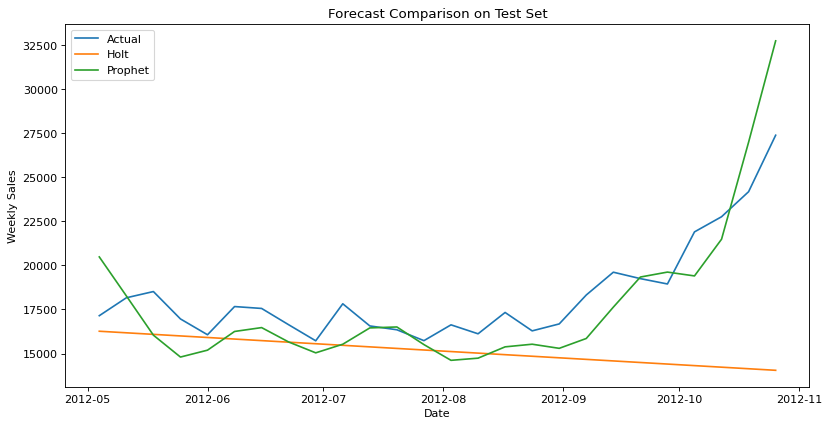

In [33]:
plt.figure(figsize=(12, 6), dpi=80)
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(holt_forecast.index, holt_forecast, label="Holt")
plt.plot(prophet_forecast.index, prophet_forecast, label="Prophet")
plt.title("Forecast Comparison on Test Set")
plt.xlabel("Date"); plt.ylabel("Weekly Sales")
plt.legend()
plt.show()
